### Introduction

Analyzing the forecast dataset and its accuracy, as mentioned in the assignment, considering data from January 2025 onwards. This analysis focuses on understanding forecast errors and evaluating how reliably wind power can meet electricity demand based on historical generation.

In [141]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

In [142]:
url = "https://data.elexon.co.uk/bmrs/api/v1/datasets/FUELHH/stream"

params = {
    "settlementDateFrom": "2025-01-01",
    "settlementDateTo": "2026-03-16",
    "fuelType": "WIND",
}

response = requests.get(url, params=params)
data = response.json()
actual_df = pd.DataFrame(data)


actual_df["startTime"] = pd.to_datetime(actual_df["startTime"])
actual_df["generation"] = actual_df["generation"].astype(float)

actual_df = actual_df[["startTime", "generation"]]
actual_df = actual_df[actual_df["generation"] > 0]
actual_df.head()

,startTime,generation
0,2026-03-16 23:30:00+00:00,15847.0
1,2026-03-16 23:00:00+00:00,15927.0
2,2026-03-16 22:30:00+00:00,16184.0
3,2026-03-16 22:00:00+00:00,16323.0
4,2026-03-16 21:30:00+00:00,16252.0


In [143]:
url = "https://data.elexon.co.uk/bmrs/api/v1/datasets/WINDFOR/stream"

params = {
    "publishDateTimeFrom": "2025-01-01",
    "publishDateTimeTo": "2026-03-16",
}

response = requests.get(url, params=params)
data = response.json()

forecast_df = pd.DataFrame(data)

forecast_df["startTime"] = pd.to_datetime(forecast_df["startTime"])
forecast_df["publishTime"] = pd.to_datetime(forecast_df["publishTime"])
forecast_df["generation"] = forecast_df["generation"].astype(float)

forecast_df = forecast_df[forecast_df["generation"] > 0]
forecast_df.head()

,dataset,publishTime,startTime,generation
0,WINDFOR,2026-03-15 22:30:00+00:00,2026-03-14 21:00:00+00:00,3858.0
1,WINDFOR,2026-03-15 22:30:00+00:00,2026-03-14 22:00:00+00:00,4271.0
2,WINDFOR,2026-03-15 22:30:00+00:00,2026-03-14 23:00:00+00:00,4488.0
3,WINDFOR,2026-03-15 22:30:00+00:00,2026-03-15 00:00:00+00:00,5647.0
4,WINDFOR,2026-03-15 22:30:00+00:00,2026-03-15 01:00:00+00:00,7018.0


In [144]:
forecast_df["horizon_hours"] = (
    forecast_df["startTime"] - forecast_df["publishTime"]
).dt.total_seconds() / 3600

forecast_df = forecast_df[
    (forecast_df["horizon_hours"] >= 0) &
    (forecast_df["horizon_hours"] <= 48)
]

forecast_df.head()

,dataset,publishTime,startTime,generation,horizon_hours
26,WINDFOR,2026-03-15 22:30:00+00:00,2026-03-15 23:00:00+00:00,19278.0,0.5
27,WINDFOR,2026-03-15 22:30:00+00:00,2026-03-16 00:00:00+00:00,19427.0,1.5
28,WINDFOR,2026-03-15 22:30:00+00:00,2026-03-16 01:00:00+00:00,19464.0,2.5
29,WINDFOR,2026-03-15 22:30:00+00:00,2026-03-16 02:00:00+00:00,19381.0,3.5
30,WINDFOR,2026-03-15 22:30:00+00:00,2026-03-16 03:00:00+00:00,19326.0,4.5


In [145]:
merged = pd.merge(
    forecast_df,
    actual_df,
    on="startTime",
    suffixes=("_forecast", "_actual"),
    how="inner"
)

merged.head()

,dataset,publishTime,startTime,generation_forecast,horizon_hours,generation_actual
0,WINDFOR,2026-03-15 22:30:00+00:00,2026-03-15 23:00:00+00:00,19278.0,0.5,16464.0
1,WINDFOR,2026-03-15 22:30:00+00:00,2026-03-16 00:00:00+00:00,19427.0,1.5,16568.0
2,WINDFOR,2026-03-15 22:30:00+00:00,2026-03-16 01:00:00+00:00,19464.0,2.5,16622.0
3,WINDFOR,2026-03-15 22:30:00+00:00,2026-03-16 02:00:00+00:00,19381.0,3.5,16196.0
4,WINDFOR,2026-03-15 22:30:00+00:00,2026-03-16 03:00:00+00:00,19326.0,4.5,16007.0


In [146]:
merged["error"] = merged["generation_forecast"] - merged["generation_actual"]

merged["absolute_error"] = merged["error"].abs()
mean_error = merged["absolute_error"].mean()
median_error = merged["absolute_error"].median()
p99_error = merged["absolute_error"].quantile(0.99)

merged.head()

,dataset,publishTime,startTime,generation_forecast,horizon_hours,generation_actual,error,absolute_error
0,WINDFOR,2026-03-15 22:30:00+00:00,2026-03-15 23:00:00+00:00,19278.0,0.5,16464.0,2814.0,2814.0
1,WINDFOR,2026-03-15 22:30:00+00:00,2026-03-16 00:00:00+00:00,19427.0,1.5,16568.0,2859.0,2859.0
2,WINDFOR,2026-03-15 22:30:00+00:00,2026-03-16 01:00:00+00:00,19464.0,2.5,16622.0,2842.0,2842.0
3,WINDFOR,2026-03-15 22:30:00+00:00,2026-03-16 02:00:00+00:00,19381.0,3.5,16196.0,3185.0,3185.0
4,WINDFOR,2026-03-15 22:30:00+00:00,2026-03-16 03:00:00+00:00,19326.0,4.5,16007.0,3319.0,3319.0


In [147]:
merged["generation_actual"].describe()

count    167494.000000
mean       8398.828776
std        4493.380834
min         101.000000
25%        4602.000000
50%        7986.500000
75%       12140.000000
max       18372.000000
Name: generation_actual, dtype: float64

In [148]:
print(f"Mean error: {mean_error} \nMedian Error: {median_error} \np99 error: {p99_error}")

Mean error: 1670.6322077208736 
Median Error: 1284.0 
p99 error: 5932.0


In [149]:
merged["forecast_error_percentage"] = (
    merged["absolute_error"] / merged["generation_actual"]
) * 100

avg_error_percentage = merged["forecast_error_percentage"].mean()
print(f"Avg error percentage: {avg_error_percentage}%")

Avg error percentage: 25.89143906262146%


### Forecast Error Statistics

The mean absolute forecast error is approximately **1671 MW**, while the median error is **1284 MW**. The mean being higher than the median indicates a **right-skewed distribution**, suggesting the presence of occasional large errors that increase the average.

The typical forecast error (~1.3–1.7 GW) is lower than earlier observations, indicating improved accuracy or more stable conditions in the selected time range. However, the gap between mean and median highlights that while most forecasts are reasonably accurate, some periods experience significantly larger deviations.

The **p99 error of approximately 5932 MW** indicates that in the worst 1% of cases, forecast errors can be extremely large. These rare but substantial deviations are likely caused by sudden and unpredictable changes in wind conditions.

The **average error percentage of 25.9%** shows that forecasts deviate by roughly one-quarter of actual generation on average. Despite lower absolute errors, the relatively high percentage error suggests that variability in wind generation remains significant, especially during periods of lower output.

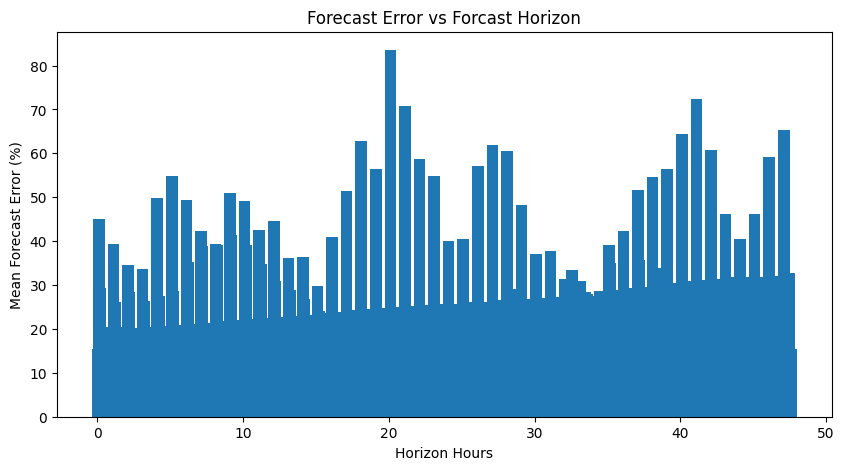

In [157]:
horizon_hours_error_percentage = merged.groupby("horizon_hours")["forecast_error_percentage"].mean()

plt.figure(figsize=(10,5))
plt.bar(horizon_hours_error_percentage.index, horizon_hours_error_percentage.values)
plt.xlabel("Horizon Hours")
plt.ylabel("Mean Forecast Error (%)")
plt.title("Forecast Error vs Forcast Horizon")
plt.show()

### Forecast Error vs Forecast Horizon

The relationship between forecast error and forecast horizon shows **no clear monotonic trend**. Instead of steadily increasing with horizon, the error fluctuates significantly across different time horizons.

Short-term forecasts (0–6 hours) exhibit moderate error levels (~30–50%), while certain mid-range horizons (around 18–24 hours) show **notable spikes**, with errors exceeding **70–80%**. Similarly, longer horizons (36–48 hours) also display elevated error levels in some intervals.

This irregular pattern suggests that forecast accuracy is not solely dependent on horizon length. Instead, it is likely influenced by **changing weather conditions**, model behavior at specific lead times, or variability in wind generation itself.

The presence of sharp spikes indicates that there are specific horizons where the model struggles significantly, possibly due to:
- transitions in weather systems  
- model update cycles  
- increased uncertainty in atmospheric conditions  

Overall, the results indicate that while forecast horizon has some influence on accuracy, **wind forecast errors are highly variable and not strictly increasing with time**, highlighting the complexity of predicting wind generation.

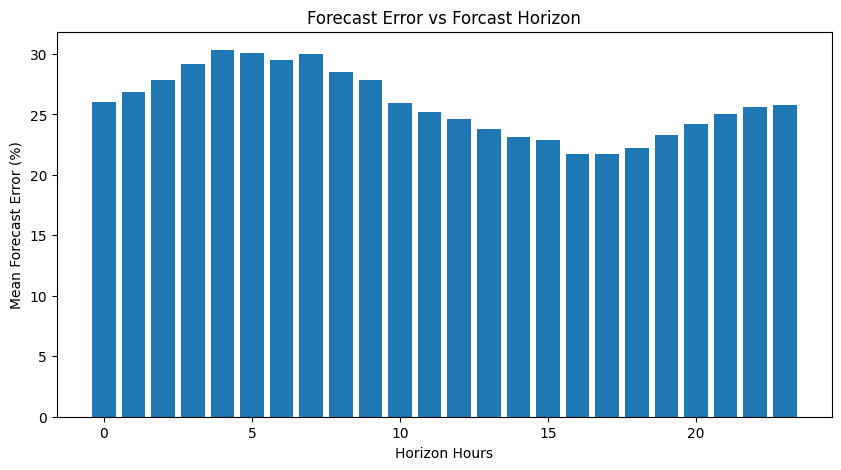

In [151]:
merged["hour"] = merged["startTime"].dt.hour
time_of_day_error_percentage = merged.groupby("hour")["forecast_error_percentage"].mean()

plt.figure(figsize=(10,5))
plt.bar(time_of_day_error_percentage.index, time_of_day_error_percentage.values)
plt.xlabel("Horizon Hours")
plt.ylabel("Mean Forecast Error (%)")
plt.title("Forecast Error vs Forcast Horizon")
plt.show()

### Forecast Error vs Forecast Horizon

The relationship between forecast error and forecast horizon shows a **non-linear but structured pattern**. Forecast error initially increases from around **26% at very short horizons** to a peak of approximately **30–31% at 4–7 hours ahead**, indicating reduced accuracy in short-term predictions beyond the immediate horizon.

Beyond this point, forecast error gradually decreases, reaching a minimum of around **21–22% at horizons near 15–17 hours**. This suggests that forecasts in the mid-range horizon are relatively more stable and accurate.

At longer horizons (20–24 hours), the error begins to increase slightly again, stabilizing around **24–26%**, indicating a moderate decline in accuracy as uncertainty in weather conditions grows.

Overall, the results suggest that:
- Very short-term forecasts are not always the most accurate due to local variability  
- Mid-range forecasts (~12–18 hours) show improved stability  
- Longer horizons introduce increasing uncertainty, but not drastically  

This pattern highlights that wind forecast accuracy depends not only on horizon length but also on atmospheric dynamics and model behavior at different lead times.

In [152]:
actual_df["generation"].describe()

count    21116.000000
mean      8406.947339
std       4497.279982
min         86.000000
25%       4610.000000
50%       8004.000000
75%      12149.250000
max      18439.000000
Name: generation, dtype: float64

In [153]:
actual_df["generation"].quantile([0.01, 0.05, 0.10, 0.25, 0.50])

0.01     746.0
0.05    1885.0
0.10    2633.0
0.25    4610.0
0.50    8004.0
Name: generation, dtype: float64

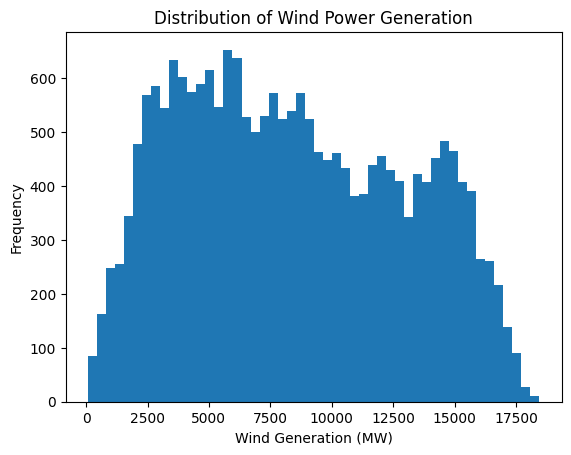

In [154]:
plt.hist(actual_df["generation"], bins=50)
plt.xlabel("Wind Generation (MW)")
plt.ylabel("Frequency")
plt.title("Distribution of Wind Power Generation")
plt.show()

### Reliable Wind Power Capacity

Wind generation shows significant variability, with output ranging from below **1 GW** to over **8 GW** at the median level. While the median generation is approximately **8004 MW**, relying on this value would be unrealistic due to frequent low-generation periods.

To estimate reliable wind capacity, a percentile-based approach was used. The 10th percentile generation is approximately **2633 MW**, meaning that wind generation exceeds this level in **90% of observed periods**.

Therefore, a reasonable estimate of reliable wind power capacity is approximately **2.6 GW**. This provides a balanced trade-off between reliability and utilization, ensuring that this level of wind generation can be depended upon most of the time.

For more conservative planning, the 5th percentile (~1.9 GW) could be used, especially in systems requiring higher reliability.

This analysis highlights that although wind generation can reach much higher levels, only a relatively small portion can be considered reliably available due to its dependence on weather conditions.

### Conclusion

This analysis highlights the inherent uncertainty and variability in wind power generation and its forecasting. While the forecasting model demonstrates moderate accuracy, with an average error of approximately **25.9%**, the presence of significant deviations—particularly in extreme cases (p99 error ~5.9 GW)—indicates that wind forecasts cannot be fully relied upon for precise planning.

The analysis of forecast error across horizon and time of day shows that accuracy is not strictly dependent on prediction length and varies with atmospheric conditions, reinforcing the complexity of wind behavior.

Most importantly, the historical generation analysis reveals substantial variability in wind output. Although the median generation is around **8 GW**, wind generation frequently drops to much lower levels. Using a percentile-based reliability approach, the **10th percentile (~2.6 GW)** provides a realistic estimate of dependable wind capacity, meaning this level of generation is available in approximately **90% of cases**.

Overall, while wind power contributes significantly to total generation, only a limited portion can be considered reliably available. This underscores the need for complementary energy sources, reserve margins, or storage solutions to ensure a stable and resilient electricity supply.